# Credit Risk Modeling in Python

https://www.datacamp.com/courses/credit-risk-modeling-in-python

## Block 1 - Exploring and Preparing Loan Data

**Credit risk** = Calculated risk difference between lending someone money and a government bond

The likelihood that someone will default on a loan is the **probability of default** (PD)

**Expected loss** = (Probability of Default) * (Exposure At Default) * (Loss Given Default)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load data set
cr_loan = pd.read_csv("cr_loan2.csv")

cr_loan.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Explore the credit data

**loan_status** shows whether the loan is currently in default with 1 being default and 0 being non-default

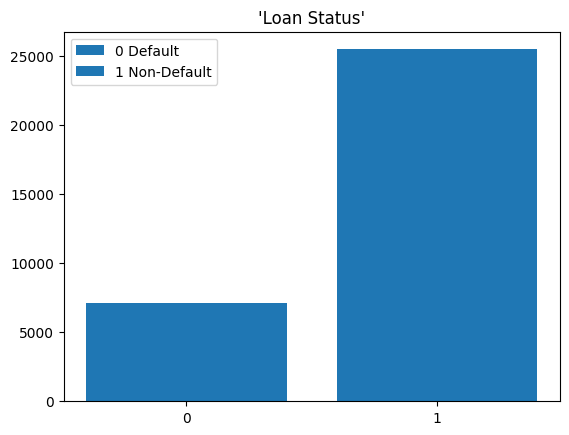

In [5]:
# Bar plot for Loan Status

legend = ["0 Default", "1 Non-Default"]
plt.bar(cr_loan["loan_status"].unique(), cr_loan["loan_status"].value_counts().values, tick_label=cr_loan["loan_status"].unique(), label=legend)
plt.title("'Loan Status'")
plt.legend()

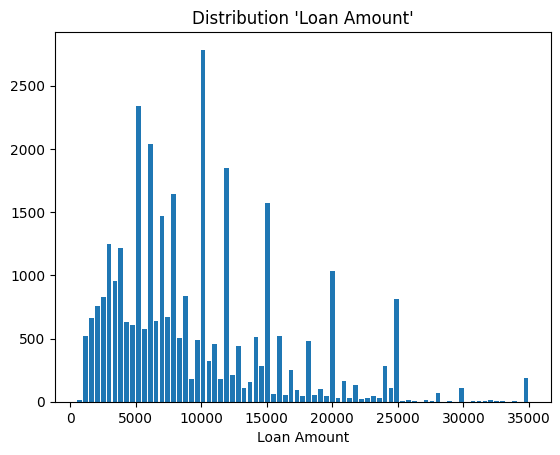

In [6]:
# Histogram for Distribution of Loan Amount

n, bins, patches = plt.hist(cr_loan["loan_amnt"], bins="auto", rwidth=0.8)
plt.title("Distribution 'Loan Amount'")
plt.xlabel("Loan Amount")
plt.show()

Text(0, 0.5, 'Personal Age')

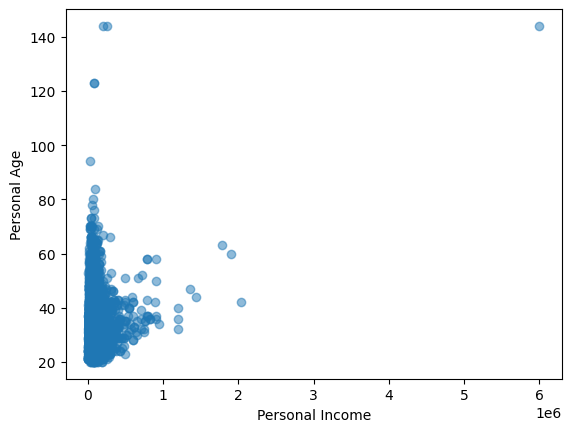

In [7]:
# Scatter plot Person Income vs Person Age

plt.scatter(cr_loan["person_income"], cr_loan["person_age"], alpha=0.5)
plt.xlabel("Personal Income")
plt.ylabel("Personal Age")

### Crosstab and pivot tables

You need to check how **loan_status** is affected by factors like home ownership status, loan grade, and loan percentage of income.

**Contingency table** = a type of table in a matrix format that displays the multivariate frequency distribution of the variables

In [8]:
# Cross table of loan_intent and loan_status.

df = pd.crosstab(cr_loan["loan_intent"], cr_loan["loan_status"], margins=True)
df

loan_status,0,1,All
loan_intent,,,
DEBTCONSOLIDATION,3722,1490,5212
EDUCATION,5342,1111,6453
HOMEIMPROVEMENT,2664,941,3605
MEDICAL,4450,1621,6071
PERSONAL,4423,1098,5521
VENTURE,4872,847,5719
All,25473,7108,32581


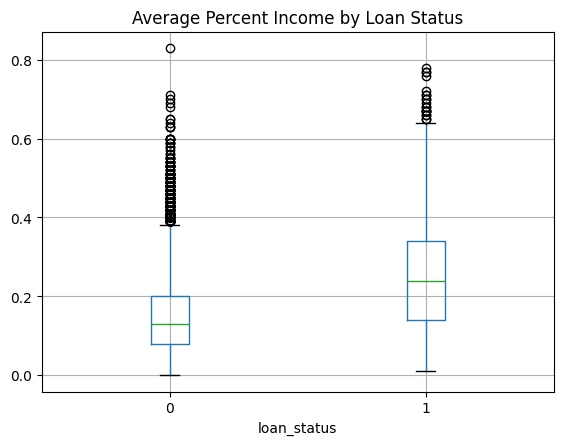

In [9]:
# Boxplot of the loan's percent of the person's income grouped by loan_status

cr_loan.boxplot(column=["loan_percent_income"], by="loan_status")
plt.title('Average Percent Income by Loan Status')
plt.suptitle('')
plt.show()

### Finding outliers with cross tables

Find and remove outliers you suspect might be in the data.

<Axes: title={'center': 'person_emp_length'}, xlabel='loan_status'>

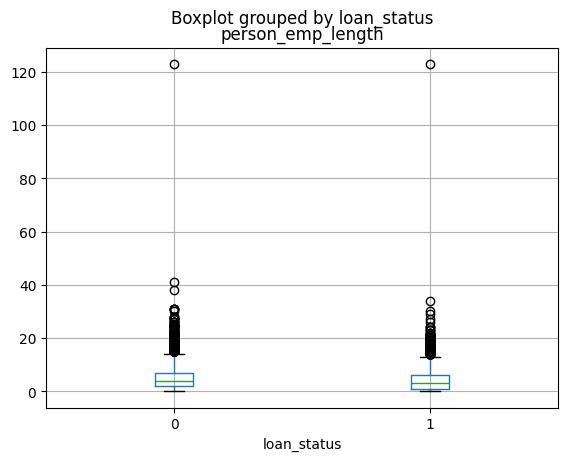

In [10]:
cr_loan.boxplot("person_emp_length", by="loan_status")

In [11]:
# Cross table of loan_status and person_home_ownership with the max person_emp_length

print(pd.crosstab(cr_loan["loan_status"], cr_loan["person_home_ownership"]))

print(pd.crosstab(cr_loan["loan_status"], cr_loan["person_home_ownership"], values=cr_loan["person_emp_length"], aggfunc="max"))

indices = cr_loan[cr_loan["person_emp_length"] > 60].index # outliers
cr_loan_new = cr_loan.drop(indices)

print(pd.crosstab(cr_loan_new["loan_status"], cr_loan_new["person_home_ownership"], values=cr_loan_new["person_emp_length"], aggfunc=["min", "max"]))

person_home_ownership  MORTGAGE  OTHER   OWN   RENT
loan_status                                        
0                         11754     74  2391  11254
1                          1690     33   193   5192
person_home_ownership  MORTGAGE  OTHER   OWN   RENT
loan_status                                        
0                         123.0   24.0  31.0   41.0
1                          34.0   11.0  17.0  123.0
                           min                      max                  
person_home_ownership MORTGAGE OTHER  OWN RENT MORTGAGE OTHER   OWN  RENT
loan_status                                                              
0                          0.0   0.0  0.0  0.0     38.0  24.0  31.0  41.0
1                          0.0   0.0  0.0  0.0     34.0  11.0  17.0  27.0


### Visualizing credit outliers

Text(0.5, 1.0, 'Without Outliers')

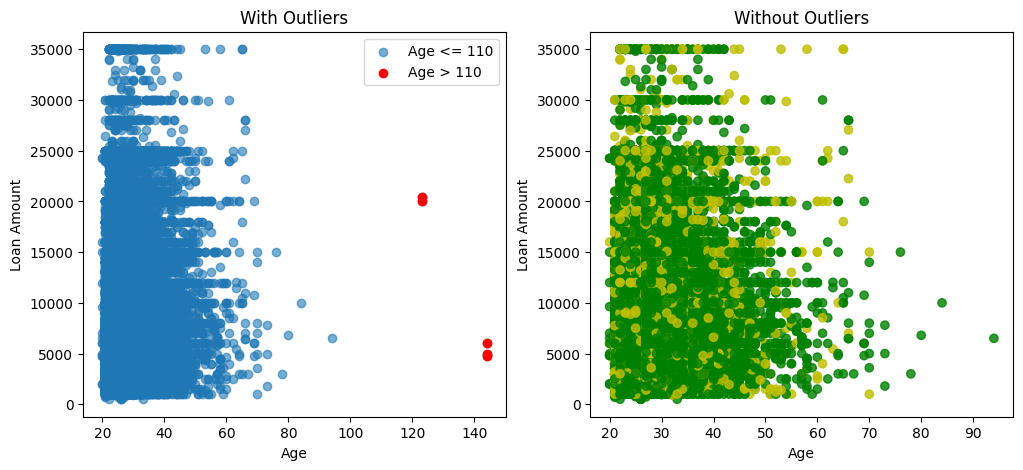

In [15]:
from matplotlib.colors import ListedColormap

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Scatter plot 1, Age  vs Loan Amount, with outliers
ax1.scatter(cr_loan["person_age"], cr_loan["loan_amnt"], label="Age <= 110", alpha=0.6)

veryold = cr_loan[cr_loan["person_age"] > 110].index # outliers
ax1.scatter(cr_loan.loc[veryold, "person_age"], cr_loan.loc[veryold, "loan_amnt"], color="red", label="Age > 110") # highlight outliers

ax1.set_xlabel("Age")
ax1.set_ylabel("Loan Amount")
ax1.set_title("With Outliers")
ax1.legend()

# Scatter plot 2, Age  vs Loan Amount, clean
cr_loan_new = cr_loan.drop(veryold)
cmap = ListedColormap(['g', 'y'])
ax2.scatter(cr_loan_new["person_age"], cr_loan_new["loan_amnt"], c=cr_loan_new["loan_status"], cmap=cmap, alpha=0.8)
ax2.set_xlabel("Age")
ax2.set_ylabel("Loan Amount")
ax2.set_title("Without Outliers")

### Replacing missing credit data


person_age                    False
person_income                 False
person_home_ownership         False
person_emp_length              True
loan_intent                   False
loan_grade                    False
loan_amnt                     False
loan_int_rate                  True
loan_status                   False
loan_percent_income           False
cb_person_default_on_file     False
cb_person_cred_hist_length    False
dtype: bool
       person_age  person_income person_home_ownership  person_emp_length  \
39             23          71500                  RENT                3.0   
50             24          78000                  RENT                4.0   
57             23         277000                   OWN                3.0   
59             24          12000                   OWN                2.0   
62             26         263000              MORTGAGE                0.0   
...           ...            ...                   ...                ...   
32547          53

C:\Users\local_ULKHAMP\Temp\ipykernel_11268\987750284.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr_loan["person_emp_length"].fillna(cr_loan["person_emp_length"].median(), inplace=True)


Text(0.5, 1.0, "Distribution for 'person_emp_length'")

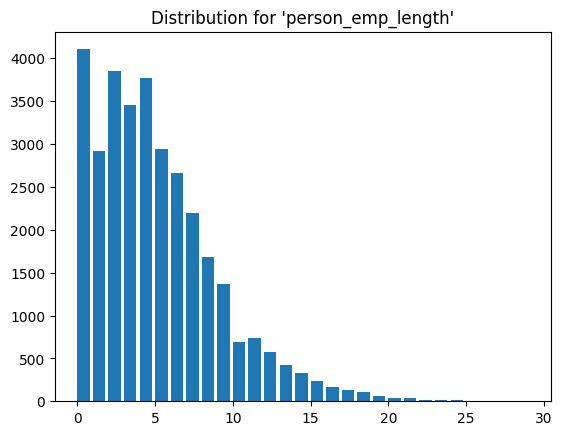

In [16]:
# Columns with Null values
print(cr_loan.isnull().any())

# Rows with Null values
print(cr_loan[cr_loan.isnull().any(axis=1)])

# Fill Null values, with median
cr_loan["person_emp_length"].fillna(cr_loan["person_emp_length"].median(), inplace=True)

# Histogram for person_emp_length
plt.hist(cr_loan["person_emp_length"], bins=range(int(min(cr_loan["person_emp_length"])), 30), width=0.8)
plt.title("Distribution for 'person_emp_length'")